**Import tableau final**

In [1]:
!pip install --upgrade google-cloud-bigquery
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

client = bigquery.Client(project="projet-riskhorizon-2276")


In [2]:
query = """
SELECT *
FROM `projet-riskhorizon-2276.3_Mart.tableau_final_table`
"""

df = client.query(query).to_dataframe()

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,dette_externe_totale,ratio_dette_credit,nb_credits_en_retard,retard_max,montant_total_retard,nb_prolongations,nb_types_credit,nb_demandes_passees,nb_refus_internes_passes,montant_total_emprunte_passe
0,355557,0,CASH_LOANS,F,False,True,0,27000.0,45000.0,4450.5,...,122050.98,0.474226,0,0,0.0,0,2,1,0,75312.0
1,211865,0,CASH_LOANS,F,False,True,0,27000.0,45000.0,4383.0,...,637623.00,0.421575,0,0,0.0,0,2,6,0,660501.0
2,364118,0,CASH_LOANS,F,False,True,0,29250.0,45000.0,4855.5,...,NaN,NaN,<NA>,<NA>,NaN,<NA>,<NA>,5,2,207724.5
3,143626,1,CASH_LOANS,F,False,True,0,31500.0,45000.0,5076.0,...,NaN,NaN,<NA>,<NA>,NaN,<NA>,<NA>,1,0,32503.5
4,372569,0,CASH_LOANS,F,False,False,0,31500.0,45000.0,4450.5,...,29817.00,0.047083,0,0,0.0,0,2,2,0,207616.5


**corrélation entre chaque variable numérique et le TARGET**

In [3]:
import pandas as pd
import numpy as np


num_cols = df.select_dtypes(include=[np.number]).columns.drop("TARGET")

corr_target = df[num_cols].corrwith(df["TARGET"]).sort_values()
print(corr_target)

EXT_SOURCE_3                   -1.789283e-01
EXT_SOURCE_2                   -1.604703e-01
EXT_SOURCE_1                   -1.553145e-01
AGE                            -7.824120e-02
YEARS_EMPLOYED                 -4.606390e-02
AMT_GOODS_PRICE                -3.962428e-02
APPORT_ESTIME                  -3.424101e-02
nb_credits_clotures            -3.398061e-02
AMT_CREDIT                     -3.037060e-02
montant_total_emprunte_passe   -2.702643e-02
total_credit_externe           -1.410571e-02
AMT_ANNUITY                    -1.281599e-02
nb_types_credit                -4.053911e-03
AMT_INCOME_TOTAL               -3.979752e-03
Reste_a_vivre                  -3.228356e-03
SK_ID_CURR                     -2.113449e-03
Reste_a_vivre_par_personne     -1.828441e-03
AVG_CREDIT_SCORE               -1.741246e-16
nb_credits_externes             7.676552e-04
nb_prolongations                3.797838e-03
retard_max                      5.205361e-03
dette_externe_totale            7.378769e-03
montant_to

In [4]:
import plotly.express as px

fig = px.bar(
    x=corr_target.values,
    y=corr_target.index,
    orientation="h",
    title="Corrélation avec TARGET"
)

fig.show()

Variables les plus liées au défaut (corr négative)
EXT_SOURCE_3 / 2 / 1 → très importantes (fort signal)
AGE, YEARS_EMPLOYED → stabilité = moins de risque
AMT_GOODS_PRICE, AMT_CREDIT → faible mais logique

Variables positives (augmentent le risque)
nb_credits_en_retard
nb_credit_refuse
RATIO_PRET, ratio_dette_credit
nb_credits_actifs

3 familles fortes :

capacité financière
historique crédit
comportement de remboursement

Regression logistique

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pandas as pd

y = df["TARGET"]
client_id = df["SK_ID_CURR"]
X = df.drop(columns=["TARGET", "SK_ID_CURR"])

# 1. Encodage
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# 3. Imputation (IMPORTANT)
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# 5. Modèle
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

# 6. Prediction
y_train_pred = model.predict_proba(X_train_scaled)[:, 1]
y_pred = model.predict_proba(X_test_scaled)[:,1]

# 7. Score
print("AUC:", roc_auc_score(y_test, y_pred))

AUC: 0.7504972350895625


In [8]:
print("AUC train:", roc_auc_score(y_train, y_train_pred))
print("AUC test :", roc_auc_score(y_test, y_pred))

AUC train: 0.7502234407128633
AUC test : 0.7504972350895625


In [9]:
import pandas as pd
import plotly.express as px

# 1. Récupération des coefficients du modèle
coef = pd.DataFrame({
    "feature": X_train.columns, #Nom des variables
    "coef": model.coef_[0] #Le poids appris par le modèle pour chaque variable
}).sort_values("coef")

# 2. Sélection des variables les plus importantes
top = coef.tail(10)      # risque + les 10 meilleurs
bottom = coef.head(10)   # risque -

plot_df = pd.concat([bottom, top])

# 3. Création du graphique interactif
fig = px.bar(
    plot_df,
    x="coef",
    y="feature",
    orientation="h",
    title="Impact des variables sur le risque (Logistic Regression)",
    labels={"coef": "Impact sur le risque", "feature": "Variables"},
)

# 4. Ligne verticale à 0 (séparation risque / protection)
fig.add_vline(x=0, line_width=2, line_dash="dash", line_color="black")

# 5. Affichage
fig.show()

In [10]:
print(coef)

                                              feature          coef
18                                nb_credits_externes -1.136430e+00
8                                        EXT_SOURCE_2 -4.179874e-01
9                                        EXT_SOURCE_3 -4.168048e-01
29                                nb_demandes_passees -2.792934e-01
7                                        EXT_SOURCE_1 -1.918666e-01
11                                     YEARS_EMPLOYED -1.618246e-01
36                         NAME_INCOME_TYPE_PENSIONER -1.381554e-01
0                                        FLAG_OWN_CAR -1.200825e-01
43                         NAME_FAMILY_STATUS_MARRIED -7.844707e-02
28                                    nb_types_credit -7.131079e-02
32                 NAME_CONTRACT_TYPE_REVOLVING_LOANS -5.398588e-02
16                                      APPORT_ESTIME -5.388784e-02
6                                     AMT_GOODS_PRICE -4.959066e-02
34                                    CODE_GENDE

In [15]:

#transformations (Imputer + Scaler) sur TOUTES les données
X_full_scaled = scaler.transform(imputer.transform(X_encoded))

#les probabilités et le score pour tous les clients
proba_full = model.predict_proba(X_full_scaled)[:, 1]
score_full = (1 - proba_full)

# une copie du DataFrame d'origine (df) pour ne pas altérer l'original
df_final = df.copy()

#les nouvelles colonnes de prédiction
df_final["proba_defaut"] = proba_full
df_final["score"] = score_full


In [16]:
df_final.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,nb_credits_en_retard,retard_max,montant_total_retard,nb_prolongations,nb_types_credit,nb_demandes_passees,nb_refus_internes_passes,montant_total_emprunte_passe,proba_defaut,score
0,355557,0,CASH_LOANS,F,False,True,0,27000.0,45000.0,4450.5,...,0,0,0.0,0,2,1,0,75312.0,0.571818,0.428182
1,211865,0,CASH_LOANS,F,False,True,0,27000.0,45000.0,4383.0,...,0,0,0.0,0,2,6,0,660501.0,0.105633,0.894367
2,364118,0,CASH_LOANS,F,False,True,0,29250.0,45000.0,4855.5,...,<NA>,<NA>,NaN,<NA>,<NA>,5,2,207724.5,0.482700,0.517300
3,143626,1,CASH_LOANS,F,False,True,0,31500.0,45000.0,5076.0,...,<NA>,<NA>,NaN,<NA>,<NA>,1,0,32503.5,0.481215,0.518785
4,372569,0,CASH_LOANS,F,False,False,0,31500.0,45000.0,4450.5,...,0,0,0.0,0,2,2,0,207616.5,0.081990,0.918010


In [17]:
import plotly.express as px

fig = px.box(
    df_final,
    x="TARGET",
    y="score",
    title="Distribution du Score par TARGET",
    labels={
        "TARGET": "Target (0: Non-défaut, 1: Défaut)",
        "score": "Score de Probabilité (1-Proba_Défaut)"
    },
    category_orders={"TARGET": [0, 1]} # Ensure order of categories
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [20]:
import plotly.express as px

fig = px.box(
    df_final,
    x="TARGET",
    y="proba_defaut",
    title="Distribution de la probabilté de défaut par TARGET",
    labels={
        "TARGET": "Target (0: Non-défaut, 1: Défaut)",
        "score": "Proba_Défaut"
    },
    category_orders={"TARGET": [0, 1]} # Ensure order of categories
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

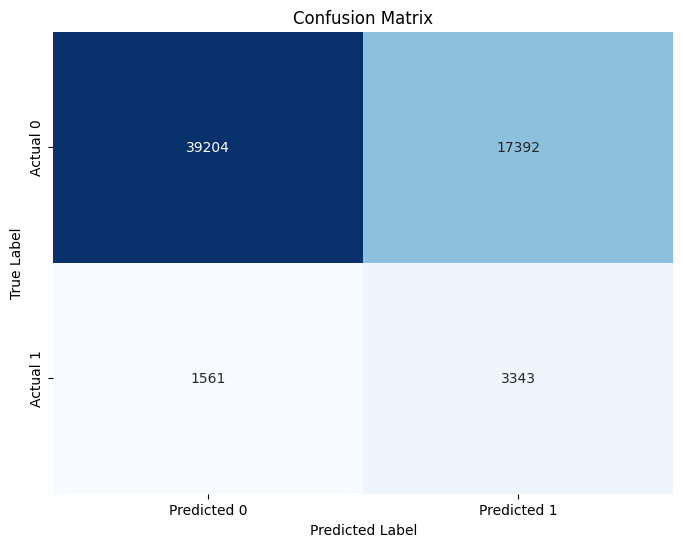

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [21]:
from google.cloud import bigquery

# Define your BigQuery project, dataset, and table name
project_id = "projet-riskhorizon-2276"
dataset_id = "3_Mart"
table_id = "tableau_final_LogisticRegression"

destination_table = f"{project_id}.{dataset_id}.{table_id}"

# Export df_final to BigQuery
df_final.to_gbq(
    destination_table,
    project_id=project_id,
    if_exists='replace'
)

print(f"DataFrame 'df_final' successfully exported to BigQuery table: {destination_table}")

/tmp/ipykernel_73446/1009476695.py:11: FutureWarning:

to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq

100%|██████████| 1/1 [00:00<00:00, 5801.25it/s]

DataFrame 'df_final' successfully exported to BigQuery table: projet-riskhorizon-2276.3_Mart.tableau_final_LogisticRegression
